In [20]:
import pandas as pd

# File paths (adjust if you're loading from a different directory)
file_eurostat_components = "out/price/eurostat_electricity_prices_components.xlsx"
file_destatis = "out/price/destatis_electricity_prices.xlsx"
file_eurostat_biannual = "out/price/eurostat_electricity_prices_biannual.xlsx"

# Load Excel sheets
df_eurostat_components = pd.read_excel(file_eurostat_components, sheet_name="Prices")
df_destatis = pd.read_excel(file_destatis, sheet_name="Strompreise")
df_eurostat_biannual = pd.read_excel(file_eurostat_biannual, sheet_name="Strompreise_Biannual")


print("Eurostat Components:", df_eurostat_components.shape)
print("Destatis:", df_destatis.shape)
print("Eurostat Biannual:", df_eurostat_biannual.shape)


Eurostat Components: (14, 10)
Destatis: (23, 6)
Eurostat Biannual: (48, 6)


In [21]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt


# Helper func
def shade_forecast_area(ax, forecast_start_year, forecast_end_year=None, color='lightgray', alpha=0.3, label="Predicted"):
    """
    Shade forecast area on a line plot between forecast_start_year and forecast_end_year.
    
    Parameters:
    - ax: matplotlib Axes object
    - forecast_start_year: datetime.datetime
    - forecast_end_year: datetime.datetime
    - color: str
    - alpha: float
    - label: str
    """
    if forecast_end_year is None:
        forecast_end_year = ax.get_xlim()[1]

    ax.axvspan(forecast_start_year, forecast_end_year, color=color, alpha=alpha, zorder=0)

    if label:
        ax.text(
            forecast_start_year,
            ax.get_ylim()[1] * 0.95,
            label,
            verticalalignment='top',
            horizontalalignment='left',
            fontsize=12,
            color='black'
        )



# Ensure time is parsed consistently
def format_time(df):
    return df["Jahr"].astype(str) + " " + df["Halbjahr"]


df_eurostat_biannual["Period"] = format_time(df_eurostat_biannual)
df_destatis["Period"] = format_time(df_destatis)

# Align on time
merged = pd.merge(
    df_eurostat_biannual, df_destatis, on="Period", suffixes=("_eurostat", "_destatis")
)

# Sort chronologically (use correct suffix)
merged["YearHalf"] = pd.to_datetime(
    merged["Jahr_eurostat"].astype(str)
    + "-"
    + merged["Halbjahr_eurostat"].str.replace("H", ""),
    format="%Y-%m",
)
merged = merged.sort_values("YearHalf")


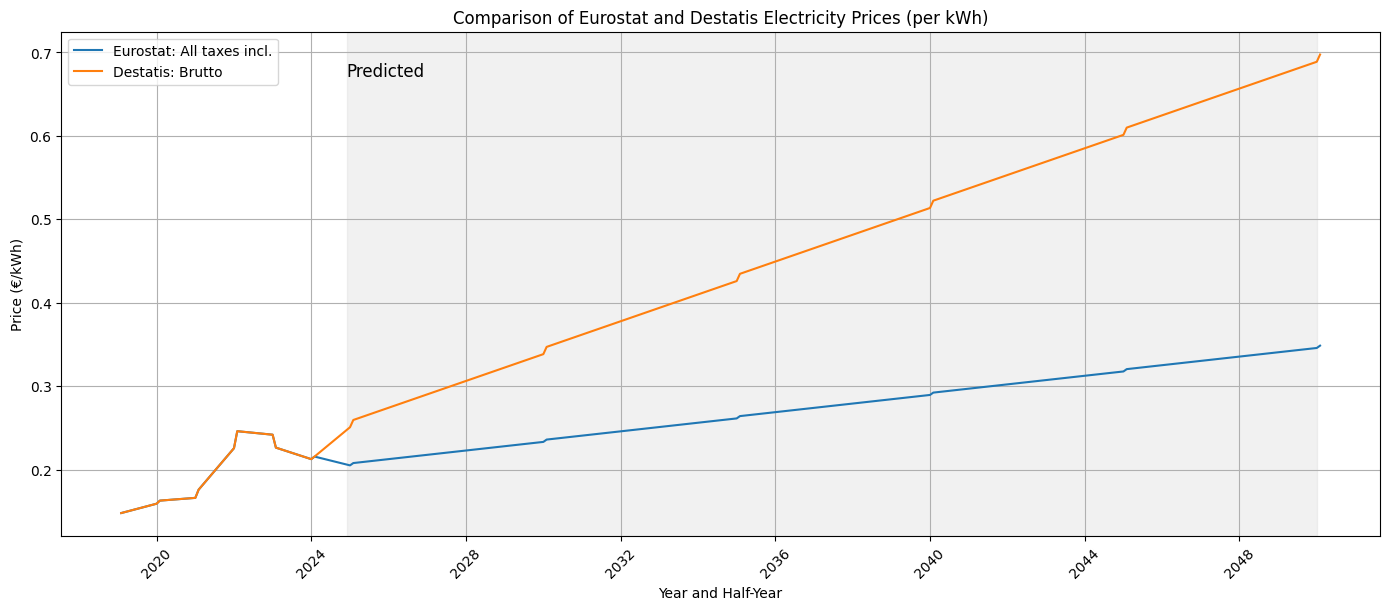

In [22]:

# Plot settings
plt.figure(figsize=(14, 6))

# --- 1. Gross Price
plt.plot(
    merged["YearHalf"],
    merged["All taxes and levies included"],
    label="Eurostat: All taxes incl.",
)
plt.plot(merged["YearHalf"], merged["Brutto"], label="Destatis: Brutto")

# --- 2. Net excl. VAT
# plt.plot(merged["YearHalf"], merged["Excluding VAT and other recoverable taxes and levies"], label="Eurostat: Excl. VAT")
# plt.plot(merged["YearHalf"], merged["Netto_ohne_USt"], label="Destatis: Netto ohne USt")

# --- 3. Net excl. all taxes
# plt.plot(merged["YearHalf"], merged["Excluding taxes and levies"], label="Eurostat: Excl. all taxes")
# plt.plot(merged["YearHalf"], merged["Netto_ohne_Abgaben"], label="Destatis: Netto ohne Abgaben")

shade_forecast_area(
    plt.gca(),
    forecast_start_year=datetime(2024, 12, 1),
    forecast_end_year=datetime(2050, 1, 1),
)
# Final plot polish
plt.title("Comparison of Eurostat and Destatis Electricity Prices (per kWh)")
plt.xlabel("Year and Half-Year")
plt.ylabel("Price (€/kWh)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)

# Add forecast shading (e.g. from 2025 onwards)


plt.show()

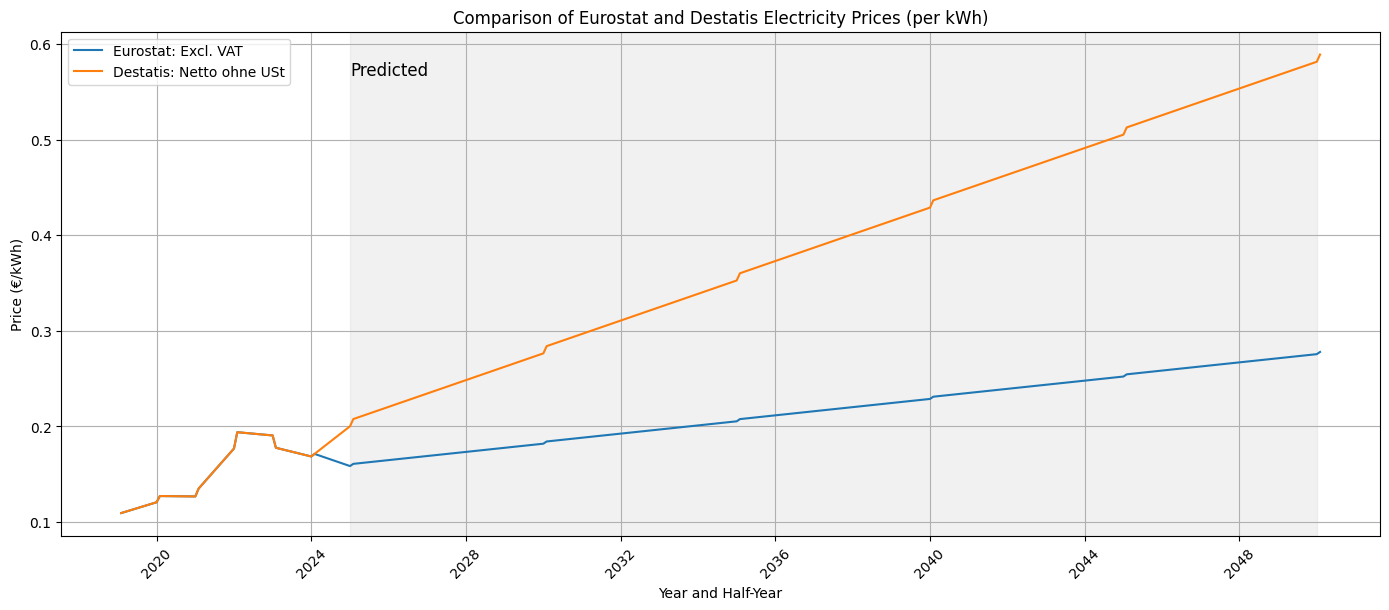

In [23]:


# Plot settings
plt.figure(figsize=(14, 6))

# --- 1. Gross Price
plt.plot(
    merged["YearHalf"],
    merged["All taxes and levies included"],
    label="Eurostat: All taxes incl.",
)
plt.plot(merged["YearHalf"], merged["Brutto"], label="Destatis: Brutto")

# --- 2. Net excl. VAT
plt.plot(merged["YearHalf"], merged["Excluding VAT and other recoverable taxes and levies"], label="Eurostat: Excl. VAT")
plt.plot(merged["YearHalf"], merged["Netto_ohne_USt"], label="Destatis: Netto ohne USt")

# --- 3. Net excl. all taxes
# plt.plot(merged["YearHalf"], merged["Excluding taxes and levies"], label="Eurostat: Excl. all taxes")
# plt.plot(merged["YearHalf"], merged["Netto_ohne_Abgaben"], label="Destatis: Netto ohne Abgaben")

shade_forecast_area(
    plt.gca(),
    forecast_start_year=datetime(2025, 1, 1),
    forecast_end_year=datetime(2050, 1, 1),
)
# Final plot polish
plt.title("Comparison of Eurostat and Destatis Electricity Prices (per kWh)")
plt.xlabel("Year and Half-Year")
plt.ylabel("Price (€/kWh)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)

# Add forecast shading (e.g. from 2025 onwards)


plt.show()

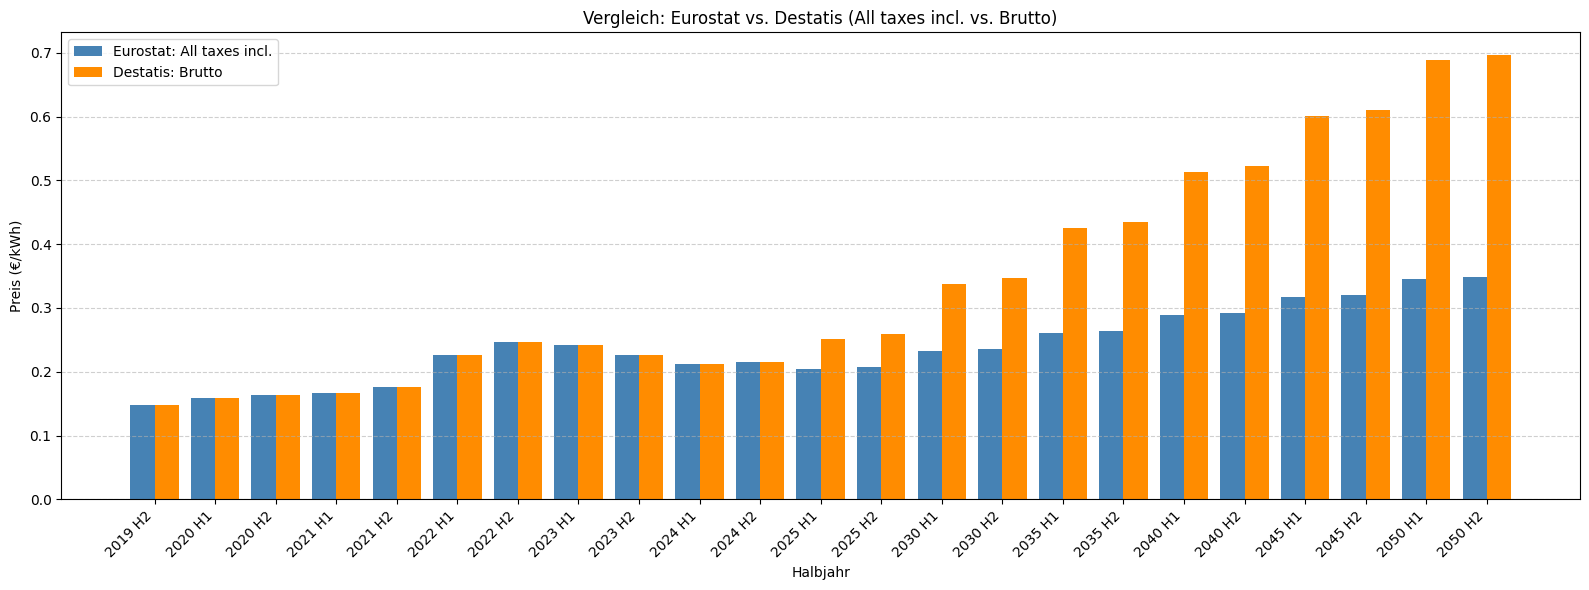

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Perioden (Jahr Hx) als Strings für die x-Achse
merged["PeriodLabel"] = merged["Jahr_eurostat"].astype(str) + " " + merged["Halbjahr_eurostat"]

# X-Positionen erzeugen
x = np.arange(len(merged))  # 0, 1, 2, ..., n
bar_width = 0.4

# Balken zeichnen
plt.figure(figsize=(16, 6))

plt.bar(
    x - bar_width / 2,
    merged["All taxes and levies included"],
    width=bar_width,
    label="Eurostat: All taxes incl.",
    color="steelblue"
)
plt.bar(
    x + bar_width / 2,
    merged["Brutto"],
    width=bar_width,
    label="Destatis: Brutto",
    color="darkorange"
)

# Achsen & Beschriftung
plt.xticks(ticks=x, labels=merged["PeriodLabel"], rotation=45, ha="right")
plt.xlabel("Halbjahr")
plt.ylabel("Preis (€/kWh)")
plt.title("Vergleich: Eurostat vs. Destatis (All taxes incl. vs. Brutto)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()
